##### purpose: explain model predictions using SHAP

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

In [3]:
#load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

#load saved model
model = joblib.load('../models/logistic_regression.pkl')

print("Everything loaded")
print(f"X_test shape : {X_test.shape}")

Everything loaded
X_test shape : (179, 7)


In [4]:
#create shap explainer
#LinearExplainer : optimised for linear models

explainer = shap.LinearExplainer(
    model, # trained logistic regression model
    X_train # training data (learns background distribution)
)

print("SHAP Explainer created")
print(f"Expected valuel: {explainer.expected_value:.4f}") # expectedd_value : baseline prediction → average model output before seeing any features

SHAP Explainer created
Expected valuel: -0.4244


In [5]:
#calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"X_test shape:      {X_test.shape}")
print(f"\nFirst passenger SHAP values:")

for feature, value in zip(X_test.columns, shap_values[0]):
    print(f"{feature:15}->{value:+.4f}")

SHAP values shape: (179, 7)
X_test shape:      (179, 7)

First passenger SHAP values:
pclass         ->-0.6783
sex            ->-1.0446
age            ->+0.2579
fare           ->+0.1080
family_size    ->-0.2951
embarked_Q     ->-0.0314
embarked_S     ->-0.0890


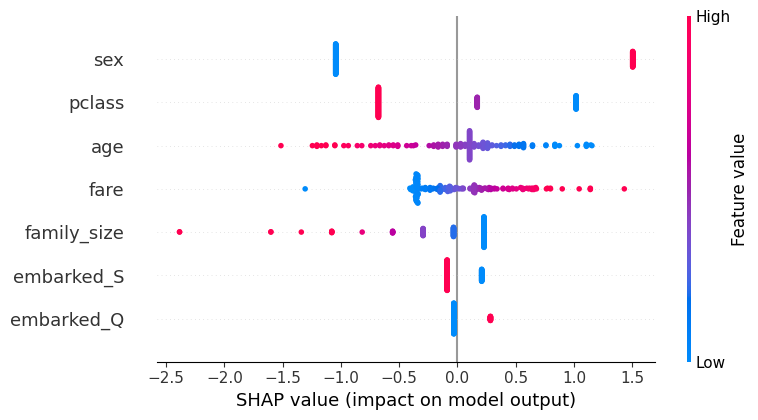

In [6]:
#Summary plot : answers which feature matter most overall
#shows SHAP values for all test passengers

shap.summary_plot(
    shap_values,
    X_test,
    show=False #dont show yet, save first
)
plt.tight_layout()
plt.savefig('../outputs/04_shap_summary.png', 
            bbox_inches='tight')
plt.show()

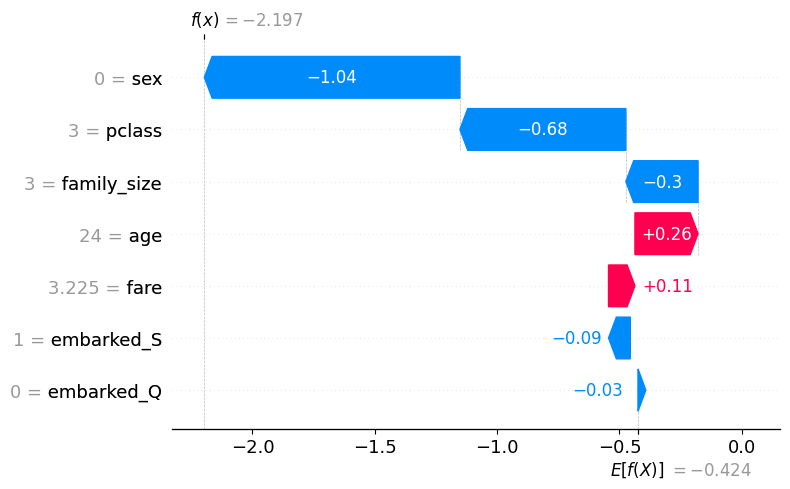

In [7]:
#waterfall plot : explain one passenger

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0], #shap values for passenger 0
        base_values= explainer.expected_value, #baseline
        data=X_test.iloc[0], #actual feature values
        feature_names = X_test.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('../outputs/05_shap_waterfall.png', bbox_inches='tight')
plt.show()